In [ ]:
# 1. IMPORT LIBRARIES
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = pd.read_csv('/content/Tweets.csv')   # make sure file exists

print("Dataset Loaded ✅")
print(df.head())
print(df.columns)


Dataset Loaded ✅
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  
Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


In [ ]:
# 3. DATA CLEANING
# =====================================
df = df[['text', 'sentiment']]
df.dropna(inplace=True)


In [ ]:
#4. PREPROCESSING
# =====================================
texts = df['text']
labels = df['sentiment']

le = LabelEncoder()
y = le.fit_transform(labels)


In [ ]:
# 5. TOKENIZATION
# =====================================
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

X = pad_sequences(sequences, maxlen=100, padding='post')

In [ ]:
# 6. TRAIN-TEST SPLIT
# =====================================
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# 7. EARLY STOPPING
# =====================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


In [ ]:
# 🔵 8. RNN MODEL
# =====================================
rnn_model = Sequential([
    Embedding(input_dim=5000, output_dim=64),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining RNN Model...\n")

rnn_history = rnn_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)


Training RNN Model...

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.3951 - loss: 1.0922 - val_accuracy: 0.4068 - val_loss: 1.0914
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3977 - loss: 1.0912 - val_accuracy: 0.4068 - val_loss: 1.0877
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.4032 - loss: 1.0896 - val_accuracy: 0.4068 - val_loss: 1.0844
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4040 - loss: 1.0877 - val_accuracy: 0.4068 - val_loss: 1.0890
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.4040 - loss: 1.0868 - val_accuracy: 0.4068 - val_loss: 1.0848


In [ ]:
# 9. RNN EVALUATION
# =====================================
print("\nRNN Evaluation:")
rnn_model.evaluate(x_test, y_test)



RNN Evaluation:
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4068 - loss: 1.0844


[1.084423542022705, 0.40684133768081665]

In [ ]:
# 🟢 10. LSTM MODEL
# =====================================
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining LSTM Model...\n")

lstm_history = lstm_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)



Training LSTM Model...

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.4040 - loss: 1.0883 - val_accuracy: 0.4068 - val_loss: 1.0869
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.4040 - loss: 1.0873 - val_accuracy: 0.4068 - val_loss: 1.0868



LSTM Evaluation:
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4068 - loss: 1.0869


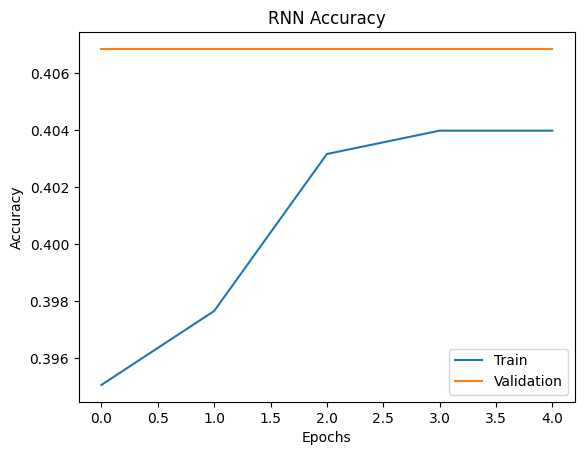

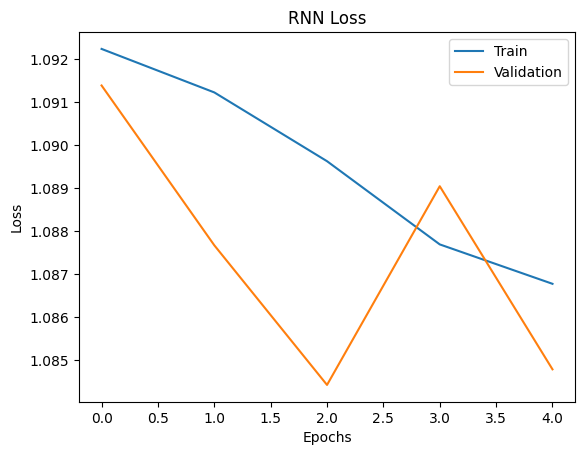

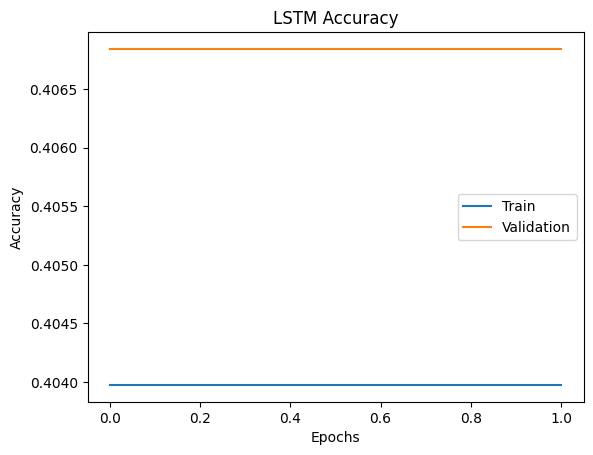

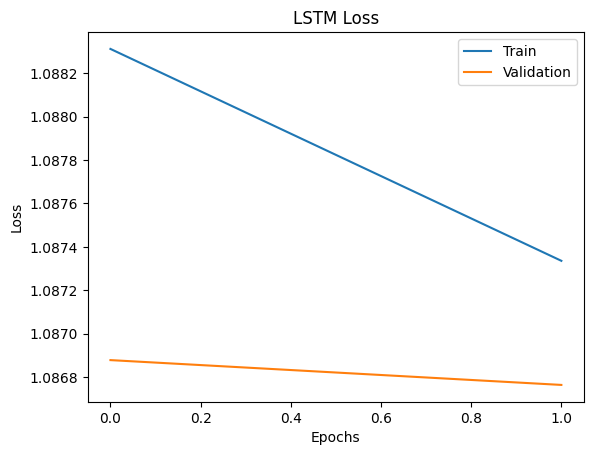

In [ ]:
# 11. LSTM EVALUATION
# =====================================
print("\nLSTM Evaluation:")
lstm_model.evaluate(x_test, y_test)


# =====================================
# 📊 12. PLOT GRAPHS
# =====================================

# ----- RNN ACCURACY -----
plt.figure()
plt.plot(rnn_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])
plt.title('RNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# ----- RNN LOSS -----
plt.figure()
plt.plot(rnn_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])
plt.title('RNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# ----- LSTM ACCURACY -----
plt.figure()
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])
plt.title('LSTM Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# ----- LSTM LOSS -----
plt.figure()
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


In [ ]:
#🔮 13. SAMPLE PREDICTION
# =====================================
sample_text = ["This is the worst experience ever"]

sample_seq = tokenizer.texts_to_sequences(sample_text)
sample_pad = pad_sequences(sample_seq, maxlen=100, padding='post')

prediction = lstm_model.predict(sample_pad)
predicted_label = np.argmax(prediction)

print("\nPredicted Sentiment:",
      le.inverse_transform([predicted_label])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step

Predicted Sentiment: neutral
